# Spine-chain score-weight experiment

This notebook finds a balanced `score_weight` for the spine-chain dynamic-programming objective. It tunes on the **validation split only**, freezes each model's selected weight, and then opens the **test split once** for confirmation.

The output is screening-oriented technical evaluation, not diagnostic accuracy. All landmark, count, and Cobb measurements require clinical review before any medical interpretation.


## Experiment design

The detector is expensive on this CPU-only machine, while changing `score_weight` affects only postprocessing. Therefore the notebook:

1. Runs each unique checkpoint once per split and caches raw predictions in original-image coordinates.
2. Holds detector and all other chain settings constant.
3. Sweeps a broad coarse weight grid, then refines within ±0.5 of the coarse winner.
4. Selects by the repository's acceptance gates, then source-macro F1@0.20D and the documented tie-breakers.
5. Writes an immutable validation recommendation before creating or reading test caches.

`best_usable_recall` and `last` are aliases of the same epoch-48 tensor state in the compaction manifest, so they are evaluated once. Run order is `best_usable_recall / last`, `best_center_f1`, then `best_loss`.


In [1]:
from __future__ import annotations

from argparse import Namespace
from collections import Counter
from dataclasses import dataclass
from datetime import datetime, timezone
from hashlib import sha256
from pathlib import Path
from typing import Any
import csv
import gc
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image as DisplayImage, Markdown, display
from torch.utils.data import DataLoader


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src" / "postprocessing" / "spine_chain.py").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the Spine-Opportunistic-Screening project root")


PROJECT_ROOT = find_project_root(Path.cwd())
EXPERIMENT_DIR = PROJECT_ROOT / "notebooks" / "experiments" / "spine chain weights"
ARTIFACT_DIR = EXPERIMENT_DIR / "artifacts"
CACHE_DIR = ARTIFACT_DIR / "cache"
FIGURE_DIR = ARTIFACT_DIR / "figures"
for directory in (ARTIFACT_DIR, CACHE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.centernet_dataset import CenterNetCocoDataset
from src.data.inference_geometry import TransformMeta
from src.evaluation.centernet_decode import decode_centernet_outputs
from src.evaluation.config import DEFAULT_ACCEPTANCE_GATES
from src.evaluation.scorecard import (
    evaluate_acceptance_gates,
    evaluate_prediction,
    postprocessing_comparison,
    scale_summary_rows,
    source_summary_rows,
)
from src.evaluate_centernet import build_model_and_settings, prediction_to_original
from src.postprocessing.spine_chain import (
    candidates_to_prediction,
    prediction_to_candidates,
    select_spine_chain,
)

print("project root:", PROJECT_ROOT)
print("experiment dir:", EXPERIMENT_DIR)
print("python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("device: CPU (the installed PyTorch build exposes neither CUDA nor MPS)")


ModuleNotFoundError: No module named 'torch'

## Fixed controls and checkpoint identities

Only `score_weight` changes. Peak threshold, top-k, duplicate handling, node threshold, minimum chain length, input geometry, split membership, and metric protocol remain fixed. This isolates the causal effect of the weight.

The broad grid includes `0.0` as a diagnostic control. Zero is never eligible for recommendation because it removes confidence contribution from the node objective.


In [ ]:
DATASET_ROOT = PROJECT_ROOT / "dataset" / "processed"
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"
COMPACT_ROOT = PROJECT_ROOT / "outputs" / "models" / "48 epochs"
COMPACTION_MANIFEST_PATH = COMPACT_ROOT / "compaction_manifest.json"
ALIAS_MANIFEST_PATH = COMPACT_ROOT / "checkpoint_aliases.json"
SPLIT_SUMMARY_PATH = DATASET_ROOT / "split_summary.json"

FIXED_SETTINGS = {
    "input_size": 1024,
    "down_ratio": 4,
    "max_objects": 64,
    "peak_thresh": 0.10,
    "topk": 50,
    "duplicate_iou": 0.18,
    "duplicate_center_scale": 0.35,
    "score_thresh": 0.18,
    "min_len": 3,
}
BATCH_SIZE = 2
NUM_WORKERS = 0
DEVICE = torch.device("cpu")
COARSE_WEIGHTS = [
    0.0, 0.10, 0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 2.50,
    3.00, 4.00, 5.00, 6.00, 8.00, 10.00, 12.00, 16.00,
]
DEFAULT_WEIGHT = 3.0
REFINE_RADIUS = 0.50
REFINE_STEP = 0.05
EXPECTED_SOURCE_COUNTS = {
    "val": {"BUU AP": 40, "Lumos AP": 16, "MICCAI-2019": 48, "Mendeley PA": 87, "NIH ChestX-ray14": 32},
    "test": {"BUU AP": 40, "Lumos AP": 16, "MICCAI-2019": 48, "Mendeley PA": 87, "NIH ChestX-ray14": 32},
}


def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


compaction_manifest = read_json(COMPACTION_MANIFEST_PATH)
alias_manifest = read_json(ALIAS_MANIFEST_PATH)
split_summary = read_json(SPLIT_SUMMARY_PATH)

alias_map = alias_manifest["checkpoint_to_representative"]
assert alias_map["best_usable_recall.pt"] == "last.pt"
assert alias_map["last.pt"] == "last.pt"
source_states = compaction_manifest["source_checkpoints"]
assert source_states["best_usable_recall.pt"]["state_sha256"] == source_states["last.pt"]["state_sha256"]
assert source_states["best_usable_recall.pt"]["source_epoch"] == source_states["last.pt"]["source_epoch"] == 48

dataset_fingerprints = compaction_manifest["dataset_fingerprints"]
assert len(dataset_fingerprints) == 1
DATASET_FINGERPRINT = dataset_fingerprints[0]


@dataclass(frozen=True)
class CheckpointSpec:
    key: str
    display_name: str
    checkpoint_path: Path
    representative_name: str
    source_epoch: int
    state_sha256: str
    existing_test_dir: Path


CHECKPOINTS = [
    CheckpointSpec(
        key="best_usable_recall_last",
        display_name="best_usable_recall / last",
        checkpoint_path=COMPACT_ROOT / "last.pt",
        representative_name="last.pt",
        source_epoch=48,
        state_sha256=source_states["last.pt"]["state_sha256"],
        existing_test_dir=PROJECT_ROOT / "outputs" / "evaluations" / "30 Aug 2026 48 epochs compact" / "last",
    ),
    CheckpointSpec(
        key="best_center_f1",
        display_name="best_center_f1",
        checkpoint_path=COMPACT_ROOT / "best_center_f1.pt",
        representative_name="best_center_f1.pt",
        source_epoch=32,
        state_sha256=source_states["best_center_f1.pt"]["state_sha256"],
        existing_test_dir=PROJECT_ROOT / "outputs" / "evaluations" / "30 Aug 2026 48 epochs compact" / "best_center_f1",
    ),
    CheckpointSpec(
        key="best_loss",
        display_name="best_loss",
        checkpoint_path=COMPACT_ROOT / "best_loss.pt",
        representative_name="best_loss.pt",
        source_epoch=35,
        state_sha256=source_states["best_loss.pt"]["state_sha256"],
        existing_test_dir=PROJECT_ROOT / "outputs" / "evaluations" / "30 Aug 2026 48 epochs compact" / "best_loss",
    ),
]

for spec in CHECKPOINTS:
    assert spec.checkpoint_path.is_file(), spec.checkpoint_path

checkpoint_table = pd.DataFrame([
    {
        "model": spec.display_name,
        "epoch": spec.source_epoch,
        "representative": spec.representative_name,
        "state_sha256": spec.state_sha256,
        "checkpoint_mb": round(spec.checkpoint_path.stat().st_size / 1024**2, 2),
    }
    for spec in CHECKPOINTS
])
display(checkpoint_table)
display(pd.DataFrame([FIXED_SETTINGS]))


,model,epoch,representative,state_sha256,checkpoint_mb
0,best_usable_recall / last,48,last.pt,eeb6b50c412853fb1565fdd056c6ed6c18bb12bac4b0de...,50.87
1,best_center_f1,32,best_center_f1.pt,51e41f0ba2f343af10e56c379de3aaaf26d522c8ccf667...,50.89
2,best_loss,35,best_loss.pt,0dd6965919d04ef55e0276f42ffea7056db8e68b546497...,50.88


,input_size,down_ratio,max_objects,peak_thresh,topk,duplicate_iou,duplicate_center_scale,score_thresh,min_len
0,1024,4,64,0.1,50,0.18,0.35,0.18,3


## Raw-prediction cache

Each cache stores padded NumPy arrays for detector scores, centers, corners, ground truth, and image/source metadata. A companion manifest binds it to the checkpoint SHA, tensor-state SHA, annotation SHA, dataset fingerprint, split, and every fixed setting. A cache is reused only if all identities and its own file checksum still match.

The chain is applied **after** predictions are transformed back to original-image pixels and predictions centered in padding are removed, matching the schema-v2 evaluator.


In [ ]:
def file_sha256(path: Path) -> str:
    digest = sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return json_safe(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        value = float(value)
    if isinstance(value, float) and not math.isfinite(value):
        return None
    if isinstance(value, Path):
        return str(value)
    return value


def write_json_atomic(path: Path, payload: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(
        json.dumps(json_safe(payload), indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    temporary.replace(path)


def value_at(value: Any, index: int) -> Any:
    item = value[index]
    return item.item() if torch.is_tensor(item) else item


def transform_meta_from_batch(batch: dict[str, Any], index: int) -> TransformMeta:
    return TransformMeta(
        original_width=int(value_at(batch["original_width"], index)),
        original_height=int(value_at(batch["original_height"], index)),
        resized_width=int(value_at(batch["resized_width"], index)),
        resized_height=int(value_at(batch["resized_height"], index)),
        pad_left=int(value_at(batch["pad_left"], index)),
        pad_top=int(value_at(batch["pad_top"], index)),
        scale=float(value_at(batch["scale"], index)),
        input_size=int(value_at(batch["input_size"], index)),
    )


def annotation_path(split: str) -> Path:
    return DATASET_ROOT / split / "_annotations.keypoints.coco.json"


def annotation_inventory(split: str) -> tuple[int, dict[str, int]]:
    coco = read_json(annotation_path(split))
    sources = Counter(str(image.get("source_dataset", "unknown")) for image in coco["images"])
    return len(coco["images"]), dict(sorted(sources.items()))


def cache_paths(spec: CheckpointSpec, split: str) -> tuple[Path, Path]:
    stem = f"{spec.key}_{split}_raw_predictions"
    return CACHE_DIR / f"{stem}.npz", CACHE_DIR / f"{stem}.manifest.json"


def expected_cache_identity(spec: CheckpointSpec, split: str) -> dict[str, Any]:
    image_count, source_counts = annotation_inventory(split)
    return {
        "schema_version": 1,
        "model_key": spec.key,
        "checkpoint_path": str(spec.checkpoint_path.resolve()),
        "checkpoint_sha256": file_sha256(spec.checkpoint_path),
        "state_sha256": spec.state_sha256,
        "source_epoch": spec.source_epoch,
        "dataset_root": str(DATASET_ROOT.resolve()),
        "dataset_version": split_summary["version"],
        "dataset_fingerprint": DATASET_FINGERPRINT,
        "split": split,
        "annotation_sha256": file_sha256(annotation_path(split)),
        "image_count": image_count,
        "source_counts": source_counts,
        "fixed_settings": FIXED_SETTINGS,
    }


def cache_is_valid(npz_path: Path, manifest_path: Path, expected: dict[str, Any]) -> bool:
    if not npz_path.is_file() or not manifest_path.is_file():
        return False
    manifest = read_json(manifest_path)
    for key, expected_value in expected.items():
        if manifest.get(key) != expected_value:
            return False
    return manifest.get("cache_sha256") == file_sha256(npz_path)


def load_prediction_cache(npz_path: Path) -> dict[str, np.ndarray]:
    with np.load(npz_path, allow_pickle=False) as archive:
        return {key: archive[key] for key in archive.files}


def research_model_args(spec: CheckpointSpec) -> Namespace:
    return Namespace(
        evaluation_profile="research",
        checkpoint=spec.checkpoint_path,
        input_size=FIXED_SETTINGS["input_size"],
        down_ratio=FIXED_SETTINGS["down_ratio"],
        max_objects=FIXED_SETTINGS["max_objects"],
        peak_thresh=FIXED_SETTINGS["peak_thresh"],
        topk=FIXED_SETTINGS["topk"],
        chain_duplicate_iou=FIXED_SETTINGS["duplicate_iou"],
        chain_duplicate_center_scale=FIXED_SETTINGS["duplicate_center_scale"],
        chain_score_thresh=FIXED_SETTINGS["score_thresh"],
        chain_score_weight=DEFAULT_WEIGHT,
        chain_min_len=FIXED_SETTINGS["min_len"],
    )


def build_prediction_cache(spec: CheckpointSpec, split: str) -> dict[str, np.ndarray]:
    npz_path, manifest_path = cache_paths(spec, split)
    expected = expected_cache_identity(spec, split)
    if cache_is_valid(npz_path, manifest_path, expected):
        print(f"cache hit: {spec.display_name} {split}")
        cache = load_prediction_cache(npz_path)
        assert len(cache["image_id"]) == expected["image_count"]
        return cache

    print(f"building cache: {spec.display_name} {split}")
    model, settings, _, resolved_checkpoint = build_model_and_settings(
        research_model_args(spec), DEVICE
    )
    assert resolved_checkpoint == spec.checkpoint_path.resolve()
    assert settings["input_size"] == FIXED_SETTINGS["input_size"]
    assert settings["peak_thresh"] == FIXED_SETTINGS["peak_thresh"]
    assert settings["topk"] == FIXED_SETTINGS["topk"]

    dataset = CenterNetCocoDataset(
        dataset_root=DATASET_ROOT,
        split=split,
        config_path=CONFIG_PATH,
        image_size=FIXED_SETTINGS["input_size"],
        down_ratio=FIXED_SETTINGS["down_ratio"],
        max_objects=FIXED_SETTINGS["max_objects"],
        augment=False,
    )
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    records: list[dict[str, Any]] = []
    model.eval()
    with torch.inference_mode():
        for batch_index, batch in enumerate(loader, start=1):
            outputs = model(batch["input"].to(DEVICE))
            decoded = decode_centernet_outputs(
                outputs,
                down_ratio=FIXED_SETTINGS["down_ratio"],
                peak_thresh=FIXED_SETTINGS["peak_thresh"],
                topk=FIXED_SETTINGS["topk"],
            )
            gt_counts = batch["gt_count"].detach().cpu().numpy().astype(int)
            gt_centers = batch["gt_centers_original"].detach().cpu().numpy()
            gt_corners = batch["gt_corners_original"].detach().cpu().numpy()
            for sample_index, padded_prediction in enumerate(decoded):
                meta = transform_meta_from_batch(batch, sample_index)
                raw = prediction_to_original(padded_prediction, meta)
                count = int(gt_counts[sample_index])
                records.append({
                    "scores": np.asarray(raw["scores"], dtype=np.float32),
                    "centers": np.asarray(raw["centers"], dtype=np.float32),
                    "corners": np.asarray(raw["corners"], dtype=np.float32),
                    "gt_centers": np.asarray(gt_centers[sample_index, :count], dtype=np.float32),
                    "gt_corners": np.asarray(gt_corners[sample_index, :count], dtype=np.float32),
                    "file_name": str(batch["file_name"][sample_index]),
                    "image_id": int(value_at(batch["image_id"], sample_index)),
                    "source_dataset": str(batch["source_dataset"][sample_index]),
                    "patient_cluster_id": str(batch["patient_cluster_id"][sample_index]),
                    "image_width": meta.original_width,
                    "image_height": meta.original_height,
                })
            if batch_index == 1 or batch_index % 10 == 0 or batch_index == len(loader):
                print(f"  [{batch_index}/{len(loader)}] {len(records)}/{len(dataset)} images", flush=True)

    del model
    gc.collect()

    image_count = len(records)
    max_predictions = max((len(record["scores"]) for record in records), default=0)
    max_ground_truth = max((len(record["gt_centers"]) for record in records), default=0)
    scores = np.full((image_count, max_predictions), np.nan, dtype=np.float32)
    centers = np.full((image_count, max_predictions, 2), np.nan, dtype=np.float32)
    corners = np.full((image_count, max_predictions, 4, 2), np.nan, dtype=np.float32)
    pred_count = np.zeros(image_count, dtype=np.int16)
    gt_center_array = np.full((image_count, max_ground_truth, 2), np.nan, dtype=np.float32)
    gt_corner_array = np.full((image_count, max_ground_truth, 4, 2), np.nan, dtype=np.float32)
    gt_count = np.zeros(image_count, dtype=np.int16)

    for index, record in enumerate(records):
        predictions = len(record["scores"])
        ground_truth = len(record["gt_centers"])
        pred_count[index] = predictions
        gt_count[index] = ground_truth
        scores[index, :predictions] = record["scores"]
        centers[index, :predictions] = record["centers"]
        corners[index, :predictions] = record["corners"]
        gt_center_array[index, :ground_truth] = record["gt_centers"]
        gt_corner_array[index, :ground_truth] = record["gt_corners"]

    arrays = {
        "scores": scores,
        "centers": centers,
        "corners": corners,
        "pred_count": pred_count,
        "gt_centers": gt_center_array,
        "gt_corners": gt_corner_array,
        "gt_count": gt_count,
        "file_name": np.asarray([record["file_name"] for record in records], dtype=np.str_),
        "image_id": np.asarray([record["image_id"] for record in records], dtype=np.int64),
        "source_dataset": np.asarray([record["source_dataset"] for record in records], dtype=np.str_),
        "patient_cluster_id": np.asarray([record["patient_cluster_id"] for record in records], dtype=np.str_),
        "image_width": np.asarray([record["image_width"] for record in records], dtype=np.int32),
        "image_height": np.asarray([record["image_height"] for record in records], dtype=np.int32),
    }
    temporary = npz_path.with_suffix(".npz.tmp")
    with temporary.open("wb") as handle:
        np.savez_compressed(handle, **arrays)
    temporary.replace(npz_path)

    observed_sources = dict(sorted(Counter(arrays["source_dataset"].tolist()).items()))
    assert image_count == expected["image_count"] == 223
    assert observed_sources == expected["source_counts"] == EXPECTED_SOURCE_COUNTS[split]
    manifest = {
        **expected,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "cache_path": str(npz_path.resolve()),
        "cache_sha256": file_sha256(npz_path),
        "max_predictions": max_predictions,
        "max_ground_truth": max_ground_truth,
    }
    write_json_atomic(manifest_path, manifest)
    print(f"cache saved: {npz_path.relative_to(PROJECT_ROOT)}")
    return arrays


## Scorecard, sweep, and deterministic selection

For every weight, this section calls the repository's existing chain selector and schema-v2 scorecard. The raw detector summary is calculated once and copied unchanged into every sweep row.

Ranking is lexicographic and validation-only:

1. All acceptance gates pass.
2. Source-macro center F1@0.20D is highest.
3. Worst-source center recall@0.20D is highest.
4. Overall usable-vertebra recall is highest.
5. Count MAE and false positives per image are lowest.
6. Exact ties prefer the value closest to the current `3.0`.


In [ ]:
def raw_prediction(cache: dict[str, np.ndarray], index: int) -> dict[str, np.ndarray]:
    count = int(cache["pred_count"][index])
    return {
        "scores": np.asarray(cache["scores"][index, :count], dtype=np.float32),
        "centers": np.asarray(cache["centers"][index, :count], dtype=np.float32),
        "corners": np.asarray(cache["corners"][index, :count], dtype=np.float32),
    }


def chain_prediction(
    prediction: dict[str, np.ndarray], weight: float
) -> tuple[dict[str, np.ndarray], tuple[int, ...]]:
    _, selected, _ = select_spine_chain(
        prediction_to_candidates(prediction),
        duplicate_iou_threshold=FIXED_SETTINGS["duplicate_iou"],
        duplicate_center_scale=FIXED_SETTINGS["duplicate_center_scale"],
        score_threshold=FIXED_SETTINGS["score_thresh"],
        score_weight=float(weight),
        min_chain_len=FIXED_SETTINGS["min_len"],
    )
    return candidates_to_prediction(selected), tuple(candidate.index for candidate in selected)


def evaluate_cache(
    cache: dict[str, np.ndarray], model_name: str, weight: float | None
) -> tuple[list[Any], str | None]:
    evaluations = []
    signature = sha256() if weight is not None else None
    for index in range(len(cache["image_id"])):
        prediction = raw_prediction(cache, index)
        if weight is not None:
            prediction, selected_indices = chain_prediction(prediction, weight)
            signature.update(np.asarray([int(cache["image_id"][index])], dtype=np.int64).tobytes())
            signature.update(np.asarray(selected_indices, dtype=np.int64).tobytes())
            signature.update(b"|")
        count = int(cache["gt_count"][index])
        evaluations.append(evaluate_prediction(
            model=model_name,
            prediction=prediction,
            gt_centers=np.asarray(cache["gt_centers"][index, :count], dtype=np.float32),
            gt_corners=np.asarray(cache["gt_corners"][index, :count], dtype=np.float32),
            image=str(cache["file_name"][index]),
            image_id=int(cache["image_id"][index]),
            source_dataset=str(cache["source_dataset"][index]),
            cluster_id=str(cache["patient_cluster_id"][index]),
            image_width=int(cache["image_width"][index]),
            image_height=int(cache["image_height"][index]),
        ))
    return evaluations, signature.hexdigest() if signature is not None else None


def summarize_evaluations(evaluations: list[Any], model_name: str) -> dict[str, Any]:
    overall, by_source, source_macro, worst_source = source_summary_rows(evaluations, model_name)
    by_scale, by_source_scale = scale_summary_rows(evaluations, model_name)
    return {
        "overall": overall,
        "source_macro": source_macro,
        "worst_source": worst_source,
        "by_source": by_source,
        "by_scale": by_scale,
        "by_source_scale": by_source_scale,
    }


def evaluate_weight(
    cache: dict[str, np.ndarray], raw_summary: dict[str, Any], weight: float
) -> dict[str, Any]:
    chain_evaluations, signature = evaluate_cache(cache, "spine_chain", weight)
    chain_summary = summarize_evaluations(chain_evaluations, "spine_chain")
    comparison = postprocessing_comparison(raw_summary["overall"], chain_summary["overall"])
    acceptance = evaluate_acceptance_gates(
        chain_overall=chain_summary["overall"],
        chain_source_macro=chain_summary["source_macro"],
        chain_worst_source=chain_summary["worst_source"],
        comparison=comparison,
    )
    return {
        "weight": float(weight),
        "diagnostic_only": bool(np.isclose(weight, 0.0)),
        "raw": raw_summary,
        "chain": chain_summary,
        "comparison": comparison,
        "acceptance": acceptance,
        "selection_signature": signature,
    }


def detail_to_row(spec: CheckpointSpec, split: str, detail: dict[str, Any]) -> dict[str, Any]:
    overall = detail["chain"]["overall"]
    macro = detail["chain"]["source_macro"]
    worst = detail["chain"]["worst_source"]
    raw = detail["raw"]["overall"]
    comparison = detail["comparison"]
    failed_gates = [
        name for name, check in detail["acceptance"]["checks"].items()
        if not check["passed"]
    ]
    return {
        "model_key": spec.key,
        "model": spec.display_name,
        "epoch": spec.source_epoch,
        "split": split,
        "weight": float(detail["weight"]),
        "diagnostic_only": bool(detail["diagnostic_only"]),
        "acceptance_passed": bool(detail["acceptance"]["passed"] and not detail["diagnostic_only"]),
        "failed_gates": ",".join(failed_gates),
        "source_macro_center_f1_0.20d": macro.get("center_f1_0.20d"),
        "worst_source_center_recall_0.20d": worst.get("center_recall_0.20d"),
        "overall_center_precision_0.20d": overall.get("center_precision_0.20d"),
        "overall_center_recall_0.20d": overall.get("center_recall_0.20d"),
        "overall_center_f1_0.20d": overall.get("center_f1_0.20d"),
        "overall_usable_vertebra_recall": overall.get("usable_vertebra_recall"),
        "overall_false_positives_per_image": overall.get("false_positives_per_image"),
        "overall_count_mae": overall.get("count_mae"),
        "overall_count_bias": overall.get("count_bias"),
        "overall_corner_nme_mean": overall.get("corner_nme_mean"),
        "overall_pck_0.10": overall.get("pck_0.10"),
        "overall_cobb_coverage": overall.get("cobb_coverage"),
        "overall_cobb_mae_deg": overall.get("cobb_mae_deg"),
        "overall_cobb_at_5deg": overall.get("cobb_at_5deg"),
        "overall_cobb_at_10deg": overall.get("cobb_at_10deg"),
        "false_positive_reduction": comparison.get("false_positive_reduction"),
        "recall_loss_0.20d": comparison.get("recall_loss_0.20d"),
        "raw_center_f1_0.20d": raw.get("center_f1_0.20d"),
        "raw_center_recall_0.20d": raw.get("center_recall_0.20d"),
        "raw_false_positives_per_image": raw.get("false_positives_per_image"),
        "selection_signature": detail["selection_signature"],
    }


def finite_or(value: Any, default: float) -> float:
    if value is None:
        return default
    numeric = float(value)
    return numeric if math.isfinite(numeric) else default


def selection_key(row: dict[str, Any]) -> tuple[Any, ...]:
    return (
        bool(row["acceptance_passed"]),
        finite_or(row["source_macro_center_f1_0.20d"], -math.inf),
        finite_or(row["worst_source_center_recall_0.20d"], -math.inf),
        finite_or(row["overall_usable_vertebra_recall"], -math.inf),
        -finite_or(row["overall_count_mae"], math.inf),
        -finite_or(row["overall_false_positives_per_image"], math.inf),
        -abs(float(row["weight"]) - DEFAULT_WEIGHT),
        -float(row["weight"]),
    )


def select_best(rows: list[dict[str, Any]]) -> dict[str, Any]:
    eligible = [row for row in rows if not row["diagnostic_only"]]
    if not eligible:
        raise RuntimeError("Sweep contains no eligible positive weights")
    return max(eligible, key=selection_key)


def fine_weights_around(weight: float) -> list[float]:
    lower = max(0.05, float(weight) - REFINE_RADIUS)
    upper = float(weight) + REFINE_RADIUS
    count = int(round((upper - lower) / REFINE_STEP))
    return [round(lower + index * REFINE_STEP, 4) for index in range(count + 1)]


def run_validation_sweep(spec: CheckpointSpec, cache: dict[str, np.ndarray]) -> dict[str, Any]:
    model_dir = ARTIFACT_DIR / spec.key
    model_dir.mkdir(parents=True, exist_ok=True)
    raw_evaluations, _ = evaluate_cache(cache, "raw", None)
    raw_summary = summarize_evaluations(raw_evaluations, "raw")

    details_by_weight: dict[float, dict[str, Any]] = {}
    for weight in COARSE_WEIGHTS:
        print(f"  coarse {spec.display_name}: weight={weight:.2f}", flush=True)
        details_by_weight[float(weight)] = evaluate_weight(cache, raw_summary, float(weight))
    coarse_rows = [detail_to_row(spec, "val", details_by_weight[float(weight)]) for weight in COARSE_WEIGHTS]
    pd.DataFrame(coarse_rows).sort_values("weight").to_csv(model_dir / "validation_coarse_sweep.csv", index=False)
    coarse_best = select_best(coarse_rows)

    for weight in fine_weights_around(float(coarse_best["weight"])):
        if weight in details_by_weight:
            continue
        print(f"  refine {spec.display_name}: weight={weight:.2f}", flush=True)
        details_by_weight[weight] = evaluate_weight(cache, raw_summary, weight)

    weights = sorted(details_by_weight)
    details = [details_by_weight[weight] for weight in weights]
    rows = [detail_to_row(spec, "val", detail) for detail in details]
    best = select_best(rows)
    baseline = next(row for row in rows if np.isclose(row["weight"], DEFAULT_WEIGHT))

    sweep_df = pd.DataFrame(rows).sort_values("weight").reset_index(drop=True)
    invariant_columns = [
        "raw_center_f1_0.20d", "raw_center_recall_0.20d", "raw_false_positives_per_image"
    ]
    raw_invariance = all(sweep_df[column].nunique(dropna=False) == 1 for column in invariant_columns)
    assert raw_invariance

    winner_detail = details_by_weight[float(best["weight"])]
    _, repeat_signature = evaluate_cache(cache, "spine_chain", float(best["weight"]))
    deterministic = repeat_signature == winner_detail["selection_signature"]
    assert deterministic

    sweep_df.to_csv(model_dir / "validation_weight_sweep.csv", index=False)
    by_source_rows = []
    for detail in details:
        for source_row in detail["chain"]["by_source"]:
            by_source_rows.append({
                "model_key": spec.key,
                "weight": detail["weight"],
                **source_row,
            })
    pd.DataFrame(by_source_rows).to_csv(model_dir / "validation_by_source.csv", index=False)
    write_json_atomic(model_dir / "validation_weight_sweep_details.json", {
        "schema_version": 1,
        "checkpoint": {
            "key": spec.key,
            "display_name": spec.display_name,
            "path": spec.checkpoint_path,
            "epoch": spec.source_epoch,
            "state_sha256": spec.state_sha256,
            "checkpoint_sha256": file_sha256(spec.checkpoint_path),
        },
        "dataset_fingerprint": DATASET_FINGERPRINT,
        "split": "val",
        "fixed_settings": FIXED_SETTINGS,
        "coarse_weights": COARSE_WEIGHTS,
        "coarse_winner": coarse_best,
        "refinement": {"radius": REFINE_RADIUS, "step": REFINE_STEP},
        "raw_summary": raw_summary,
        "weights": details,
    })
    selection = {
        "model_key": spec.key,
        "model": spec.display_name,
        "epoch": spec.source_epoch,
        "state_sha256": spec.state_sha256,
        "checkpoint_sha256": file_sha256(spec.checkpoint_path),
        "selected_weight": float(best["weight"]),
        "qualified": bool(best["acceptance_passed"]),
        "status": "qualified" if best["acceptance_passed"] else "best observed but not qualified",
        "selected_metrics": best,
        "weight_3_baseline": baseline,
        "raw_metric_invariance_passed": raw_invariance,
        "deterministic_repeat_passed": deterministic,
    }
    write_json_atomic(model_dir / "validation_selection.json", selection)
    return {
        "spec": spec,
        "cache": cache,
        "sweep": sweep_df,
        "details_by_weight": details_by_weight,
        "selection": selection,
    }


## Visualization

Each model receives a six-panel validation plot. Green dots are gate-qualified weights, the dashed gray line is the current `3.0`, and the red line is the selected validation weight. These panels make the recall-versus-suppression tradeoff visible rather than hiding it behind one score.


In [ ]:
PLOT_METRICS = [
    ("source_macro_center_f1_0.20d", "Source-macro F1 @ 0.20D", DEFAULT_ACCEPTANCE_GATES["source_macro_f1_0.20d_min"]),
    ("worst_source_center_recall_0.20d", "Worst-source recall @ 0.20D", DEFAULT_ACCEPTANCE_GATES["worst_source_recall_0.20d_min"]),
    ("overall_usable_vertebra_recall", "Usable-vertebra recall", DEFAULT_ACCEPTANCE_GATES["usable_vertebra_recall_min"]),
    ("overall_false_positives_per_image", "False positives / image", None),
    ("overall_count_mae", "Count MAE", DEFAULT_ACCEPTANCE_GATES["count_mae_max"]),
    ("overall_cobb_mae_deg", "Cobb MAE (degrees)", DEFAULT_ACCEPTANCE_GATES["cobb_mae_deg_max"]),
]


def plot_validation_sweep(run: dict[str, Any]) -> Path:
    spec = run["spec"]
    frame = run["sweep"]
    selected_weight = run["selection"]["selected_weight"]
    fig, axes = plt.subplots(3, 2, figsize=(14, 13), constrained_layout=True)
    for axis, (column, title, gate) in zip(axes.flat, PLOT_METRICS):
        axis.plot(frame["weight"], frame[column], color="#365f91", marker="o", markersize=3, linewidth=1.2)
        passing = frame[frame["acceptance_passed"]]
        axis.scatter(passing["weight"], passing[column], color="#2e8b57", s=28, label="all gates pass", zorder=3)
        axis.axvline(DEFAULT_WEIGHT, color="#777777", linestyle="--", linewidth=1.2, label="current 3.0")
        axis.axvline(selected_weight, color="#c43b3b", linewidth=1.5, label=f"selected {selected_weight:g}")
        if gate is not None:
            axis.axhline(gate, color="#b8860b", linestyle=":", linewidth=1.1, label="metric gate")
        axis.set_title(title, loc="left")
        axis.set_xlabel("score_weight")
        axis.grid(alpha=0.22)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
    fig.suptitle(
        f"Validation spine-chain weight sweep — {spec.display_name} (epoch {spec.source_epoch})",
        fontsize=15,
        y=1.02,
    )
    path = FIGURE_DIR / f"{spec.key}_validation_weight_sweep.png"
    fig.savefig(path, dpi=170, bbox_inches="tight")
    plt.close(fig)
    return path


## Validation phase — freeze before test

The following cell performs the long part of the experiment. It starts with `best_usable_recall / last`, persists its interim result, and then processes the other two unique model states. Once all validation sweeps finish, it writes `frozen_validation_recommendations.json` **before** any test cache is built.

The cell is resumable: completed raw caches are checksum-validated and reused.


In [ ]:
validation_runs: dict[str, dict[str, Any]] = {}
validation_started_at = datetime.now(timezone.utc)

for spec in CHECKPOINTS:
    print(f"\n=== VALIDATION: {spec.display_name} (epoch {spec.source_epoch}) ===", flush=True)
    validation_cache = build_prediction_cache(spec, "val")
    run = run_validation_sweep(spec, validation_cache)
    run["figure_path"] = plot_validation_sweep(run)
    validation_runs[spec.key] = run
    display(pd.DataFrame([run["selection"]["selected_metrics"]]))

ranked_validation = sorted(
    [run["selection"] for run in validation_runs.values()],
    key=lambda item: selection_key(item["selected_metrics"]),
    reverse=True,
)
for rank, item in enumerate(ranked_validation, start=1):
    item["validation_rank"] = rank

frozen_recommendations = {
    "schema_version": 1,
    "protocol": "validation-only selection frozen before test inference",
    "frozen_at_utc": datetime.now(timezone.utc).isoformat(),
    "validation_started_at_utc": validation_started_at.isoformat(),
    "selection_split": "val",
    "dataset_version": split_summary["version"],
    "dataset_fingerprint": DATASET_FINGERPRINT,
    "fixed_settings": FIXED_SETTINGS,
    "selection_rule": [
        "all acceptance gates pass",
        "highest source-macro center F1@0.20D",
        "highest worst-source center recall@0.20D",
        "highest overall usable-vertebra recall",
        "lowest count MAE",
        "lowest false positives per image",
        "closest to current weight 3.0 for exact ties",
    ],
    "ranked_recommendations": ranked_validation,
    "overall_validation_winner": ranked_validation[0],
    "test_results_consulted": False,
    "medical_scope": "Screening-oriented technical evaluation only; not diagnostic accuracy.",
}
freeze_path = ARTIFACT_DIR / "frozen_validation_recommendations.json"
if freeze_path.exists():
    prior = read_json(freeze_path)
    prior_pairs = [(row["model_key"], row["selected_weight"]) for row in prior["ranked_recommendations"]]
    new_pairs = [(row["model_key"], row["selected_weight"]) for row in ranked_validation]
    if prior_pairs != new_pairs:
        raise RuntimeError(
            "Existing frozen recommendations differ from this validation run. "
            "Move the prior artifact aside before intentionally freezing a new experiment."
        )
else:
    write_json_atomic(freeze_path, frozen_recommendations)

assert freeze_path.is_file()
print("\nFrozen before test:", freeze_path.relative_to(PROJECT_ROOT))
display(pd.DataFrame([
    {
        "validation_rank": item["validation_rank"],
        "model": item["model"],
        "epoch": item["epoch"],
        "selected_weight": item["selected_weight"],
        "status": item["status"],
        "source_macro_f1_0.20d": item["selected_metrics"]["source_macro_center_f1_0.20d"],
        "worst_source_recall_0.20d": item["selected_metrics"]["worst_source_center_recall_0.20d"],
        "usable_recall": item["selected_metrics"]["overall_usable_vertebra_recall"],
        "fp_per_image": item["selected_metrics"]["overall_false_positives_per_image"],
        "count_mae": item["selected_metrics"]["overall_count_mae"],
    }
    for item in ranked_validation
]))



=== VALIDATION: best_usable_recall / last (epoch 48) ===
building cache: best_usable_recall / last val
  [1/112] 2/223 images
  [10/112] 20/223 images
  [20/112] 40/223 images
  [30/112] 60/223 images
  [40/112] 80/223 images
  [50/112] 100/223 images
  [60/112] 120/223 images
  [70/112] 140/223 images
  [80/112] 160/223 images
  [90/112] 180/223 images
  [100/112] 200/223 images
  [110/112] 220/223 images
  [112/112] 223/223 images
cache saved: notebooks/experiments/spine chain weights/artifacts/cache/best_usable_recall_last_val_raw_predictions.npz
  coarse best_usable_recall / last: weight=0.00
  coarse best_usable_recall / last: weight=0.10
  coarse best_usable_recall / last: weight=0.25
  coarse best_usable_recall / last: weight=0.50
  coarse best_usable_recall / last: weight=0.75
  coarse best_usable_recall / last: weight=1.00
  coarse best_usable_recall / last: weight=1.50
  coarse best_usable_recall / last: weight=2.00
  coarse best_usable_recall / last: weight=2.50
  coarse be

,model_key,model,epoch,split,weight,diagnostic_only,acceptance_passed,failed_gates,source_macro_center_f1_0.20d,worst_source_center_recall_0.20d,...,overall_cobb_coverage,overall_cobb_mae_deg,overall_cobb_at_5deg,overall_cobb_at_10deg,false_positive_reduction,recall_loss_0.20d,raw_center_f1_0.20d,raw_center_recall_0.20d,raw_false_positives_per_image,selection_signature
0,best_usable_recall_last,best_usable_recall / last,48,val,0.7,False,True,,0.934848,0.904412,...,1.0,4.260382,0.820628,0.946188,0.697581,0.048387,0.908519,0.971102,2.224215,69b62c01be0b0bbf4c0e0edf227ad8360201efd2d8f96f...



=== VALIDATION: best_center_f1 (epoch 32) ===
building cache: best_center_f1 val
  [1/112] 2/223 images
  [10/112] 20/223 images
  [20/112] 40/223 images
  [30/112] 60/223 images
  [40/112] 80/223 images
  [50/112] 100/223 images
  [60/112] 120/223 images
  [70/112] 140/223 images
  [80/112] 160/223 images
  [90/112] 180/223 images
  [100/112] 200/223 images
  [110/112] 220/223 images
  [112/112] 223/223 images
cache saved: notebooks/experiments/spine chain weights/artifacts/cache/best_center_f1_val_raw_predictions.npz
  coarse best_center_f1: weight=0.00
  coarse best_center_f1: weight=0.10
  coarse best_center_f1: weight=0.25
  coarse best_center_f1: weight=0.50
  coarse best_center_f1: weight=0.75
  coarse best_center_f1: weight=1.00
  coarse best_center_f1: weight=1.50
  coarse best_center_f1: weight=2.00
  coarse best_center_f1: weight=2.50
  coarse best_center_f1: weight=3.00
  coarse best_center_f1: weight=4.00
  coarse best_center_f1: weight=5.00
  coarse best_center_f1: weigh

,model_key,model,epoch,split,weight,diagnostic_only,acceptance_passed,failed_gates,source_macro_center_f1_0.20d,worst_source_center_recall_0.20d,...,overall_cobb_coverage,overall_cobb_mae_deg,overall_cobb_at_5deg,overall_cobb_at_10deg,false_positive_reduction,recall_loss_0.20d,raw_center_f1_0.20d,raw_center_recall_0.20d,raw_false_positives_per_image,selection_signature
0,best_center_f1,best_center_f1,32,val,1.5,False,True,,0.94068,0.931373,...,1.0,4.331343,0.816143,0.93722,0.671756,0.038306,0.907786,0.977487,2.349776,dcd90772d48b1b42dd3f9f614ac48d529323a6f7be0381...



=== VALIDATION: best_loss (epoch 35) ===
building cache: best_loss val
  [1/112] 2/223 images
  [10/112] 20/223 images
  [20/112] 40/223 images
  [30/112] 60/223 images
  [40/112] 80/223 images
  [50/112] 100/223 images
  [60/112] 120/223 images
  [70/112] 140/223 images
  [80/112] 160/223 images
  [90/112] 180/223 images
  [100/112] 200/223 images
  [110/112] 220/223 images
  [112/112] 223/223 images
cache saved: notebooks/experiments/spine chain weights/artifacts/cache/best_loss_val_raw_predictions.npz
  coarse best_loss: weight=0.00
  coarse best_loss: weight=0.10
  coarse best_loss: weight=0.25
  coarse best_loss: weight=0.50
  coarse best_loss: weight=0.75
  coarse best_loss: weight=1.00
  coarse best_loss: weight=1.50
  coarse best_loss: weight=2.00
  coarse best_loss: weight=2.50
  coarse best_loss: weight=3.00
  coarse best_loss: weight=4.00
  coarse best_loss: weight=5.00
  coarse best_loss: weight=6.00
  coarse best_loss: weight=8.00
  coarse best_loss: weight=10.00
  coarse

,model_key,model,epoch,split,weight,diagnostic_only,acceptance_passed,failed_gates,source_macro_center_f1_0.20d,worst_source_center_recall_0.20d,...,overall_cobb_coverage,overall_cobb_mae_deg,overall_cobb_at_5deg,overall_cobb_at_10deg,false_positive_reduction,recall_loss_0.20d,raw_center_f1_0.20d,raw_center_recall_0.20d,raw_false_positives_per_image,selection_signature
0,best_loss,best_loss,35,val,1.0,False,True,,0.937771,0.909859,...,1.0,4.331427,0.789238,0.941704,0.702804,0.042003,0.906401,0.977823,2.399103,0c3226c0abccd27465684f959938f1facbce345c4c856e...



Frozen before test: notebooks/experiments/spine chain weights/artifacts/frozen_validation_recommendations.json


,validation_rank,model,epoch,selected_weight,status,source_macro_f1_0.20d,worst_source_recall_0.20d,usable_recall,fp_per_image,count_mae
0,1,best_center_f1,32,1.5,qualified,0.940680,0.931373,0.825269,0.771300,0.829596
1,2,best_loss,35,1.0,qualified,0.937771,0.909859,0.818884,0.713004,0.878924
2,3,best_usable_recall / last,48,0.7,qualified,0.934848,0.904412,0.819892,0.672646,0.914798


## Frozen test confirmation

Only now does the notebook create/read test caches. Each model is evaluated at its frozen validation weight and at the existing `3.0` baseline. The test results are descriptive confirmation; they cannot change the selected weights or validation ranking.

As an integrity check, the `3.0` results must reproduce the repository's existing test scorecards for all three unique tensor states within CSV rounding tolerance.


In [ ]:
frozen_from_disk = read_json(freeze_path)
assert frozen_from_disk["test_results_consulted"] is False
frozen_by_key = {item["model_key"]: item for item in frozen_from_disk["ranked_recommendations"]}

TEST_REPRODUCTION_METRICS = [
    "center_f1_0.20d",
    "center_recall_0.20d",
    "false_positives_per_image",
    "count_mae",
    "usable_vertebra_recall",
    "corner_nme_mean",
    "cobb_mae_deg",
]


def existing_test_rows(spec: CheckpointSpec) -> dict[str, dict[str, str]]:
    path = spec.existing_test_dir / "metrics.csv"
    with path.open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    return {
        row["scope"]: row
        for row in rows
        if row.get("model") == "spine_chain" and row.get("scope") in {"overall_micro", "source_macro", "worst_source"}
    }


test_rows: list[dict[str, Any]] = []
test_details: dict[str, Any] = {}
reproduction_rows: list[dict[str, Any]] = []
test_started_at = datetime.now(timezone.utc)

for spec in CHECKPOINTS:
    print(f"\n=== TEST CONFIRMATION: {spec.display_name} ===", flush=True)
    cache = build_prediction_cache(spec, "test")
    raw_evaluations, _ = evaluate_cache(cache, "raw", None)
    raw_summary = summarize_evaluations(raw_evaluations, "raw")
    selected_weight = float(frozen_by_key[spec.key]["selected_weight"])
    weights = sorted({DEFAULT_WEIGHT, selected_weight})
    model_details = {}
    for weight in weights:
        print(f"  test {spec.display_name}: weight={weight:.2f}", flush=True)
        detail = evaluate_weight(cache, raw_summary, weight)
        model_details[str(weight)] = detail
        row = detail_to_row(spec, "test", detail)
        row["role"] = "frozen_winner" if np.isclose(weight, selected_weight) else "weight_3_baseline"
        if np.isclose(selected_weight, DEFAULT_WEIGHT):
            row["role"] = "frozen_winner_and_weight_3_baseline"
        test_rows.append(row)

    baseline_detail = model_details[str(DEFAULT_WEIGHT)]
    existing = existing_test_rows(spec)
    generated_scopes = {
        "overall_micro": baseline_detail["chain"]["overall"],
        "source_macro": baseline_detail["chain"]["source_macro"],
        "worst_source": baseline_detail["chain"]["worst_source"],
    }
    for scope, generated in generated_scopes.items():
        for metric in TEST_REPRODUCTION_METRICS:
            observed = generated.get(metric)
            expected_text = existing[scope].get(metric, "")
            if observed is None or expected_text == "":
                continue
            expected_value = float(expected_text)
            difference = abs(float(observed) - expected_value)
            reproduction_rows.append({
                "model_key": spec.key,
                "scope": scope,
                "metric": metric,
                "generated": float(observed),
                "existing": expected_value,
                "absolute_difference": difference,
                "passed": difference <= 2e-6,
            })

    test_details[spec.key] = {
        "checkpoint": {
            "display_name": spec.display_name,
            "epoch": spec.source_epoch,
            "state_sha256": spec.state_sha256,
            "checkpoint_sha256": file_sha256(spec.checkpoint_path),
        },
        "selected_weight": selected_weight,
        "raw_summary": raw_summary,
        "evaluated_weights": model_details,
    }
    write_json_atomic(ARTIFACT_DIR / spec.key / "test_confirmation_details.json", test_details[spec.key])

test_frame = pd.DataFrame(test_rows)
test_frame.to_csv(ARTIFACT_DIR / "test_confirmation.csv", index=False)
reproduction_frame = pd.DataFrame(reproduction_rows)
reproduction_frame.to_csv(ARTIFACT_DIR / "weight_3_baseline_reproduction.csv", index=False)
assert not reproduction_frame.empty
assert bool(reproduction_frame["passed"].all()), reproduction_frame[~reproduction_frame["passed"]]

test_winner_rows = test_frame[test_frame["role"].str.contains("frozen_winner")].copy()
test_baseline_rows = test_frame[test_frame["weight"].map(lambda value: np.isclose(value, DEFAULT_WEIGHT))].copy()

final_summary = {
    "schema_version": 1,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "test_started_at_utc": test_started_at.isoformat(),
    "frozen_recommendation_path": str(freeze_path.resolve()),
    "validation_ranking_preserved": [item["model_key"] for item in frozen_from_disk["ranked_recommendations"]],
    "fixed_settings": FIXED_SETTINGS,
    "validation_recommendations": frozen_from_disk["ranked_recommendations"],
    "test_confirmation": test_details,
    "verification": {
        "best_usable_recall_and_last_alias_verified": True,
        "cache_image_and_source_counts_verified": True,
        "raw_metrics_invariant_across_weights": all(
            run["selection"]["raw_metric_invariance_passed"] for run in validation_runs.values()
        ),
        "deterministic_repeat_verified": all(
            run["selection"]["deterministic_repeat_passed"] for run in validation_runs.values()
        ),
        "weight_3_existing_test_metrics_reproduced": bool(reproduction_frame["passed"].all()),
        "maximum_baseline_absolute_difference": float(reproduction_frame["absolute_difference"].max()),
    },
    "medical_scope": "Screening-oriented landmark and geometry evaluation only; not diagnostic accuracy.",
}
write_json_atomic(ARTIFACT_DIR / "experiment_summary.json", final_summary)
write_json_atomic(ARTIFACT_DIR / "test_confirmation_details.json", test_details)

print("All baseline reproduction checks passed.")
display(test_winner_rows[[
    "model", "epoch", "weight", "source_macro_center_f1_0.20d",
    "worst_source_center_recall_0.20d", "overall_usable_vertebra_recall",
    "overall_false_positives_per_image", "overall_count_mae", "overall_cobb_mae_deg",
    "acceptance_passed", "failed_gates",
]])



=== TEST CONFIRMATION: best_usable_recall / last ===
building cache: best_usable_recall / last test
  [1/112] 2/223 images
  [10/112] 20/223 images
  [20/112] 40/223 images
  [30/112] 60/223 images
  [40/112] 80/223 images
  [50/112] 100/223 images
  [60/112] 120/223 images
  [70/112] 140/223 images
  [80/112] 160/223 images
  [90/112] 180/223 images
  [100/112] 200/223 images
  [110/112] 220/223 images
  [112/112] 223/223 images
cache saved: notebooks/experiments/spine chain weights/artifacts/cache/best_usable_recall_last_test_raw_predictions.npz
  test best_usable_recall / last: weight=0.70
  test best_usable_recall / last: weight=3.00

=== TEST CONFIRMATION: best_center_f1 ===
building cache: best_center_f1 test
  [1/112] 2/223 images
  [10/112] 20/223 images
  [20/112] 40/223 images
  [30/112] 60/223 images
  [40/112] 80/223 images
  [50/112] 100/223 images
  [60/112] 120/223 images
  [70/112] 140/223 images
  [80/112] 160/223 images
  [90/112] 180/223 images
  [100/112] 200/223 i

,model,epoch,weight,source_macro_center_f1_0.20d,worst_source_center_recall_0.20d,overall_usable_vertebra_recall,overall_false_positives_per_image,overall_count_mae,overall_cobb_mae_deg,acceptance_passed,failed_gates
0,best_usable_recall / last,48,0.7,0.934958,0.893154,0.807190,0.681614,1.085202,4.236067,True,
2,best_center_f1,32,1.5,0.934308,0.912988,0.777124,0.766816,1.071749,4.168384,True,
4,best_loss,35,1.0,0.937037,0.912676,0.797059,0.757848,0.874439,4.061858,True,


## Interpretation and artifact index

The interpretation below is generated from the frozen validation ranking, followed by the independent test confirmation. A test improvement or regression is reported but never used to retune the weight.


### Validation-selected recommendations

- **#1 best_center_f1 (epoch 32):** `score_weight=1.5`; passed all gates. Validation source-macro F1@0.20D=0.9407, worst-source recall=0.9314, usable recall=0.8253, FP/image=0.7713, count MAE=0.8296.
- **#2 best_loss (epoch 35):** `score_weight=1`; passed all gates. Validation source-macro F1@0.20D=0.9378, worst-source recall=0.9099, usable recall=0.8189, FP/image=0.7130, count MAE=0.8789.
- **#3 best_usable_recall / last (epoch 48):** `score_weight=0.7`; passed all gates. Validation source-macro F1@0.20D=0.9348, worst-source recall=0.9044, usable recall=0.8199, FP/image=0.6726, count MAE=0.9148.

### Frozen test confirmation

- **best_center_f1:** weight `1.5` produced test source-macro F1@0.20D=0.9343, worst-source recall=0.9130, usable recall=0.7771, FP/image=0.7668, count MAE=1.0717.
- **best_loss:** weight `1` produced test source-macro F1@0.20D=0.9370, worst-source recall=0.9127, usable recall=0.7971, FP/image=0.7578, count MAE=0.8744.
- **best_usable_recall / last:** weight `0.7` produced test source-macro F1@0.20D=0.9350, worst-source recall=0.8932, usable recall=0.8072, FP/image=0.6816, count MAE=1.0852.

The overall recommendation remains the validation winner; the test split was not used for model or weight selection.

These are technical screening-support measurements, not evidence that an image proves a spinal condition.

,artifact,size_kb
0,artifacts/best_center_f1/test_confirmation_det...,436.0
1,artifacts/best_center_f1/validation_by_source.csv,267.4
2,artifacts/best_center_f1/validation_coarse_swe...,9.1
3,artifacts/best_center_f1/validation_selection....,3.0
4,artifacts/best_center_f1/validation_weight_swe...,17.6
5,artifacts/best_center_f1/validation_weight_swe...,5935.5
6,artifacts/best_loss/test_confirmation_details....,436.6
7,artifacts/best_loss/validation_by_source.csv,258.3
8,artifacts/best_loss/validation_coarse_sweep.csv,8.9
9,artifacts/best_loss/validation_selection.json,3.0


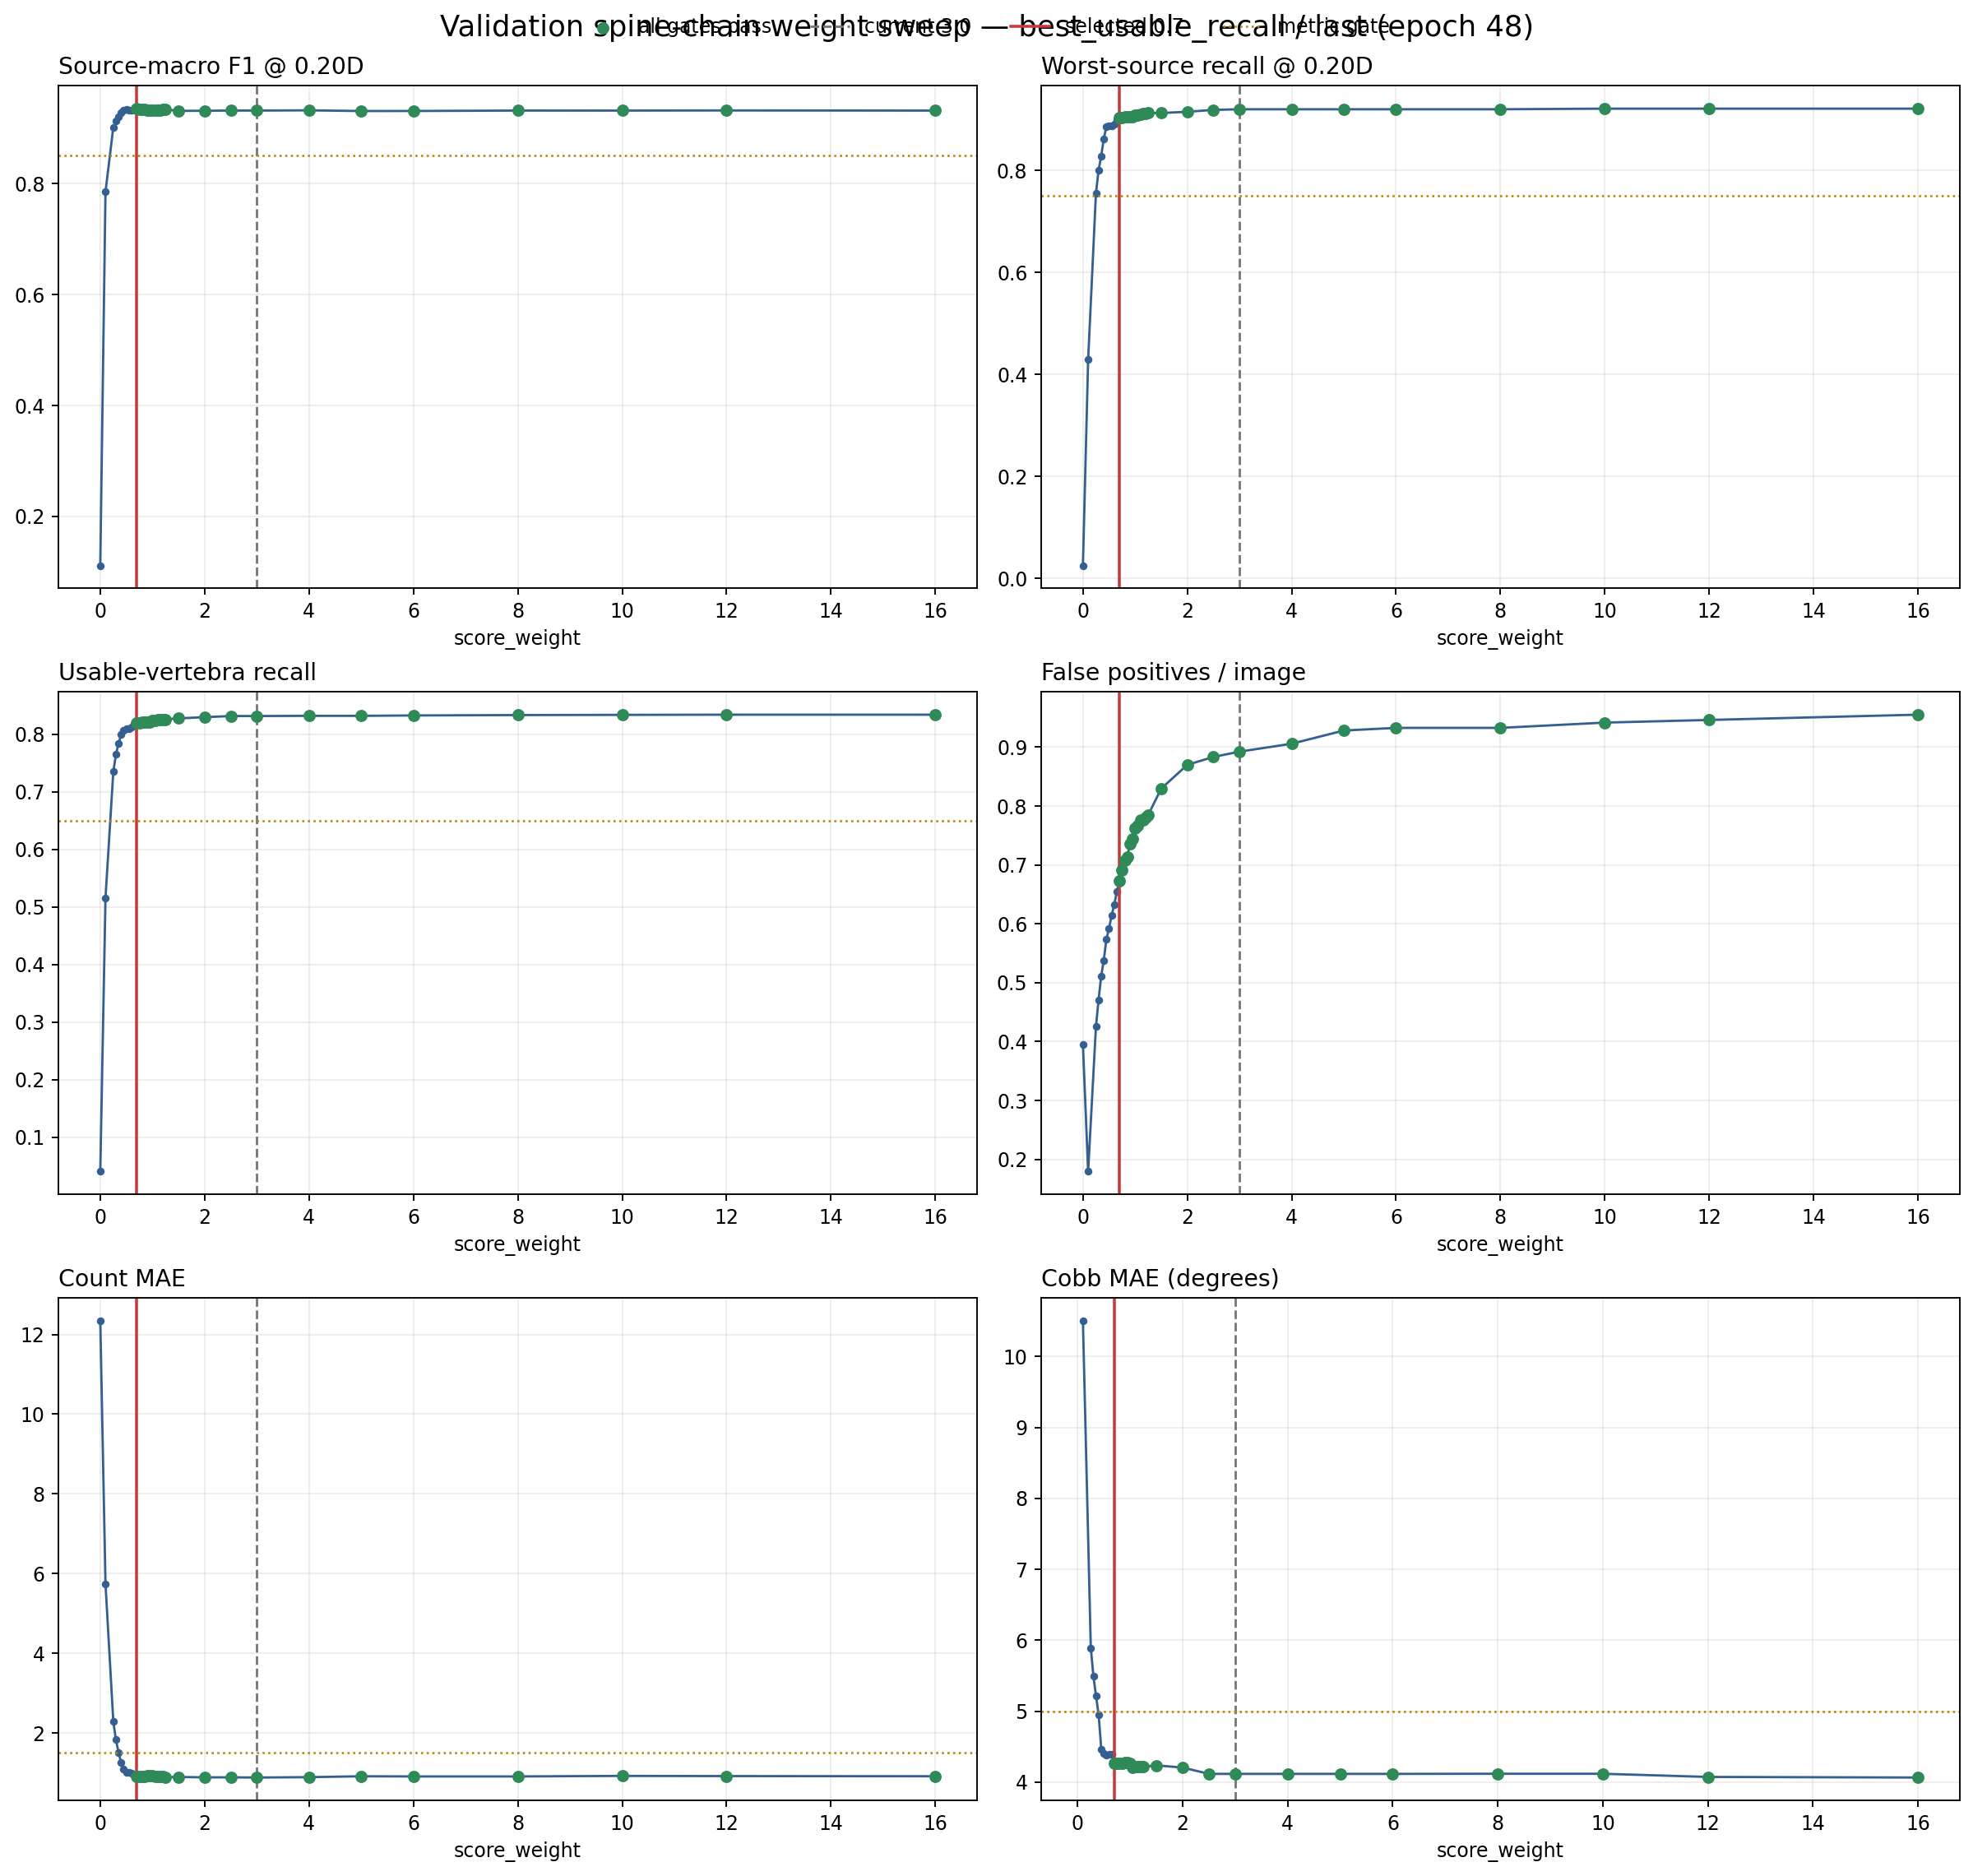

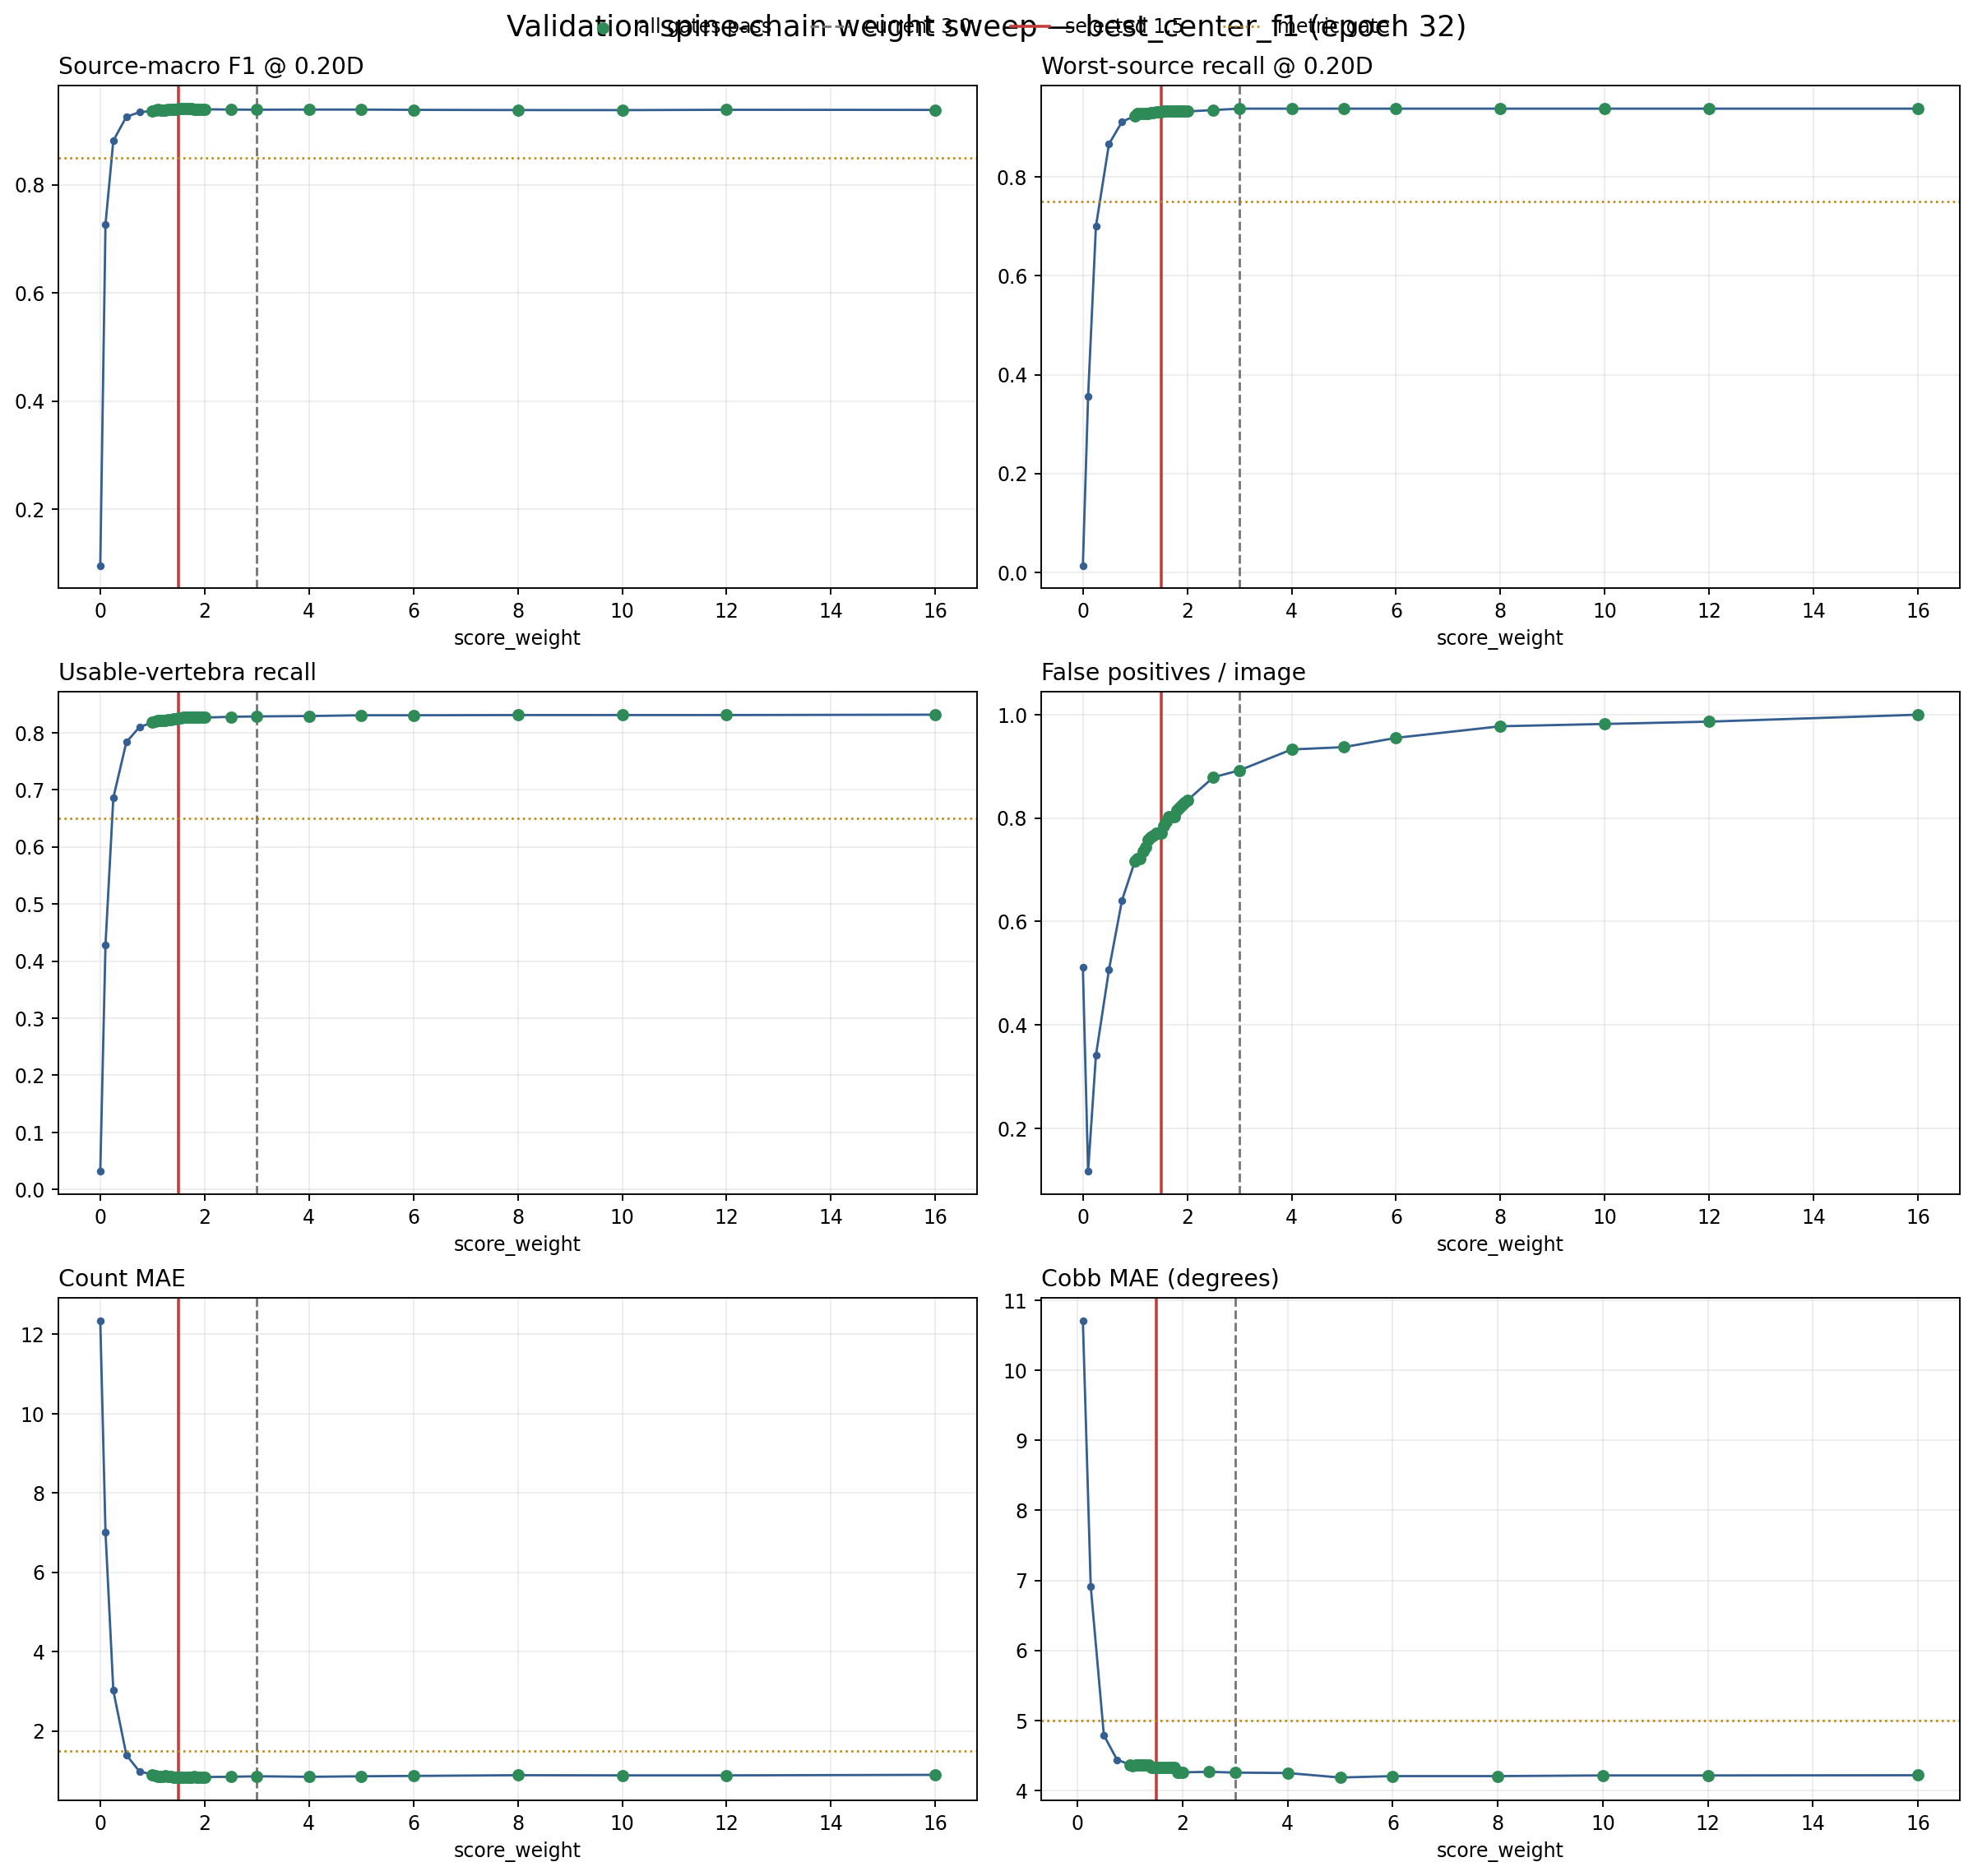

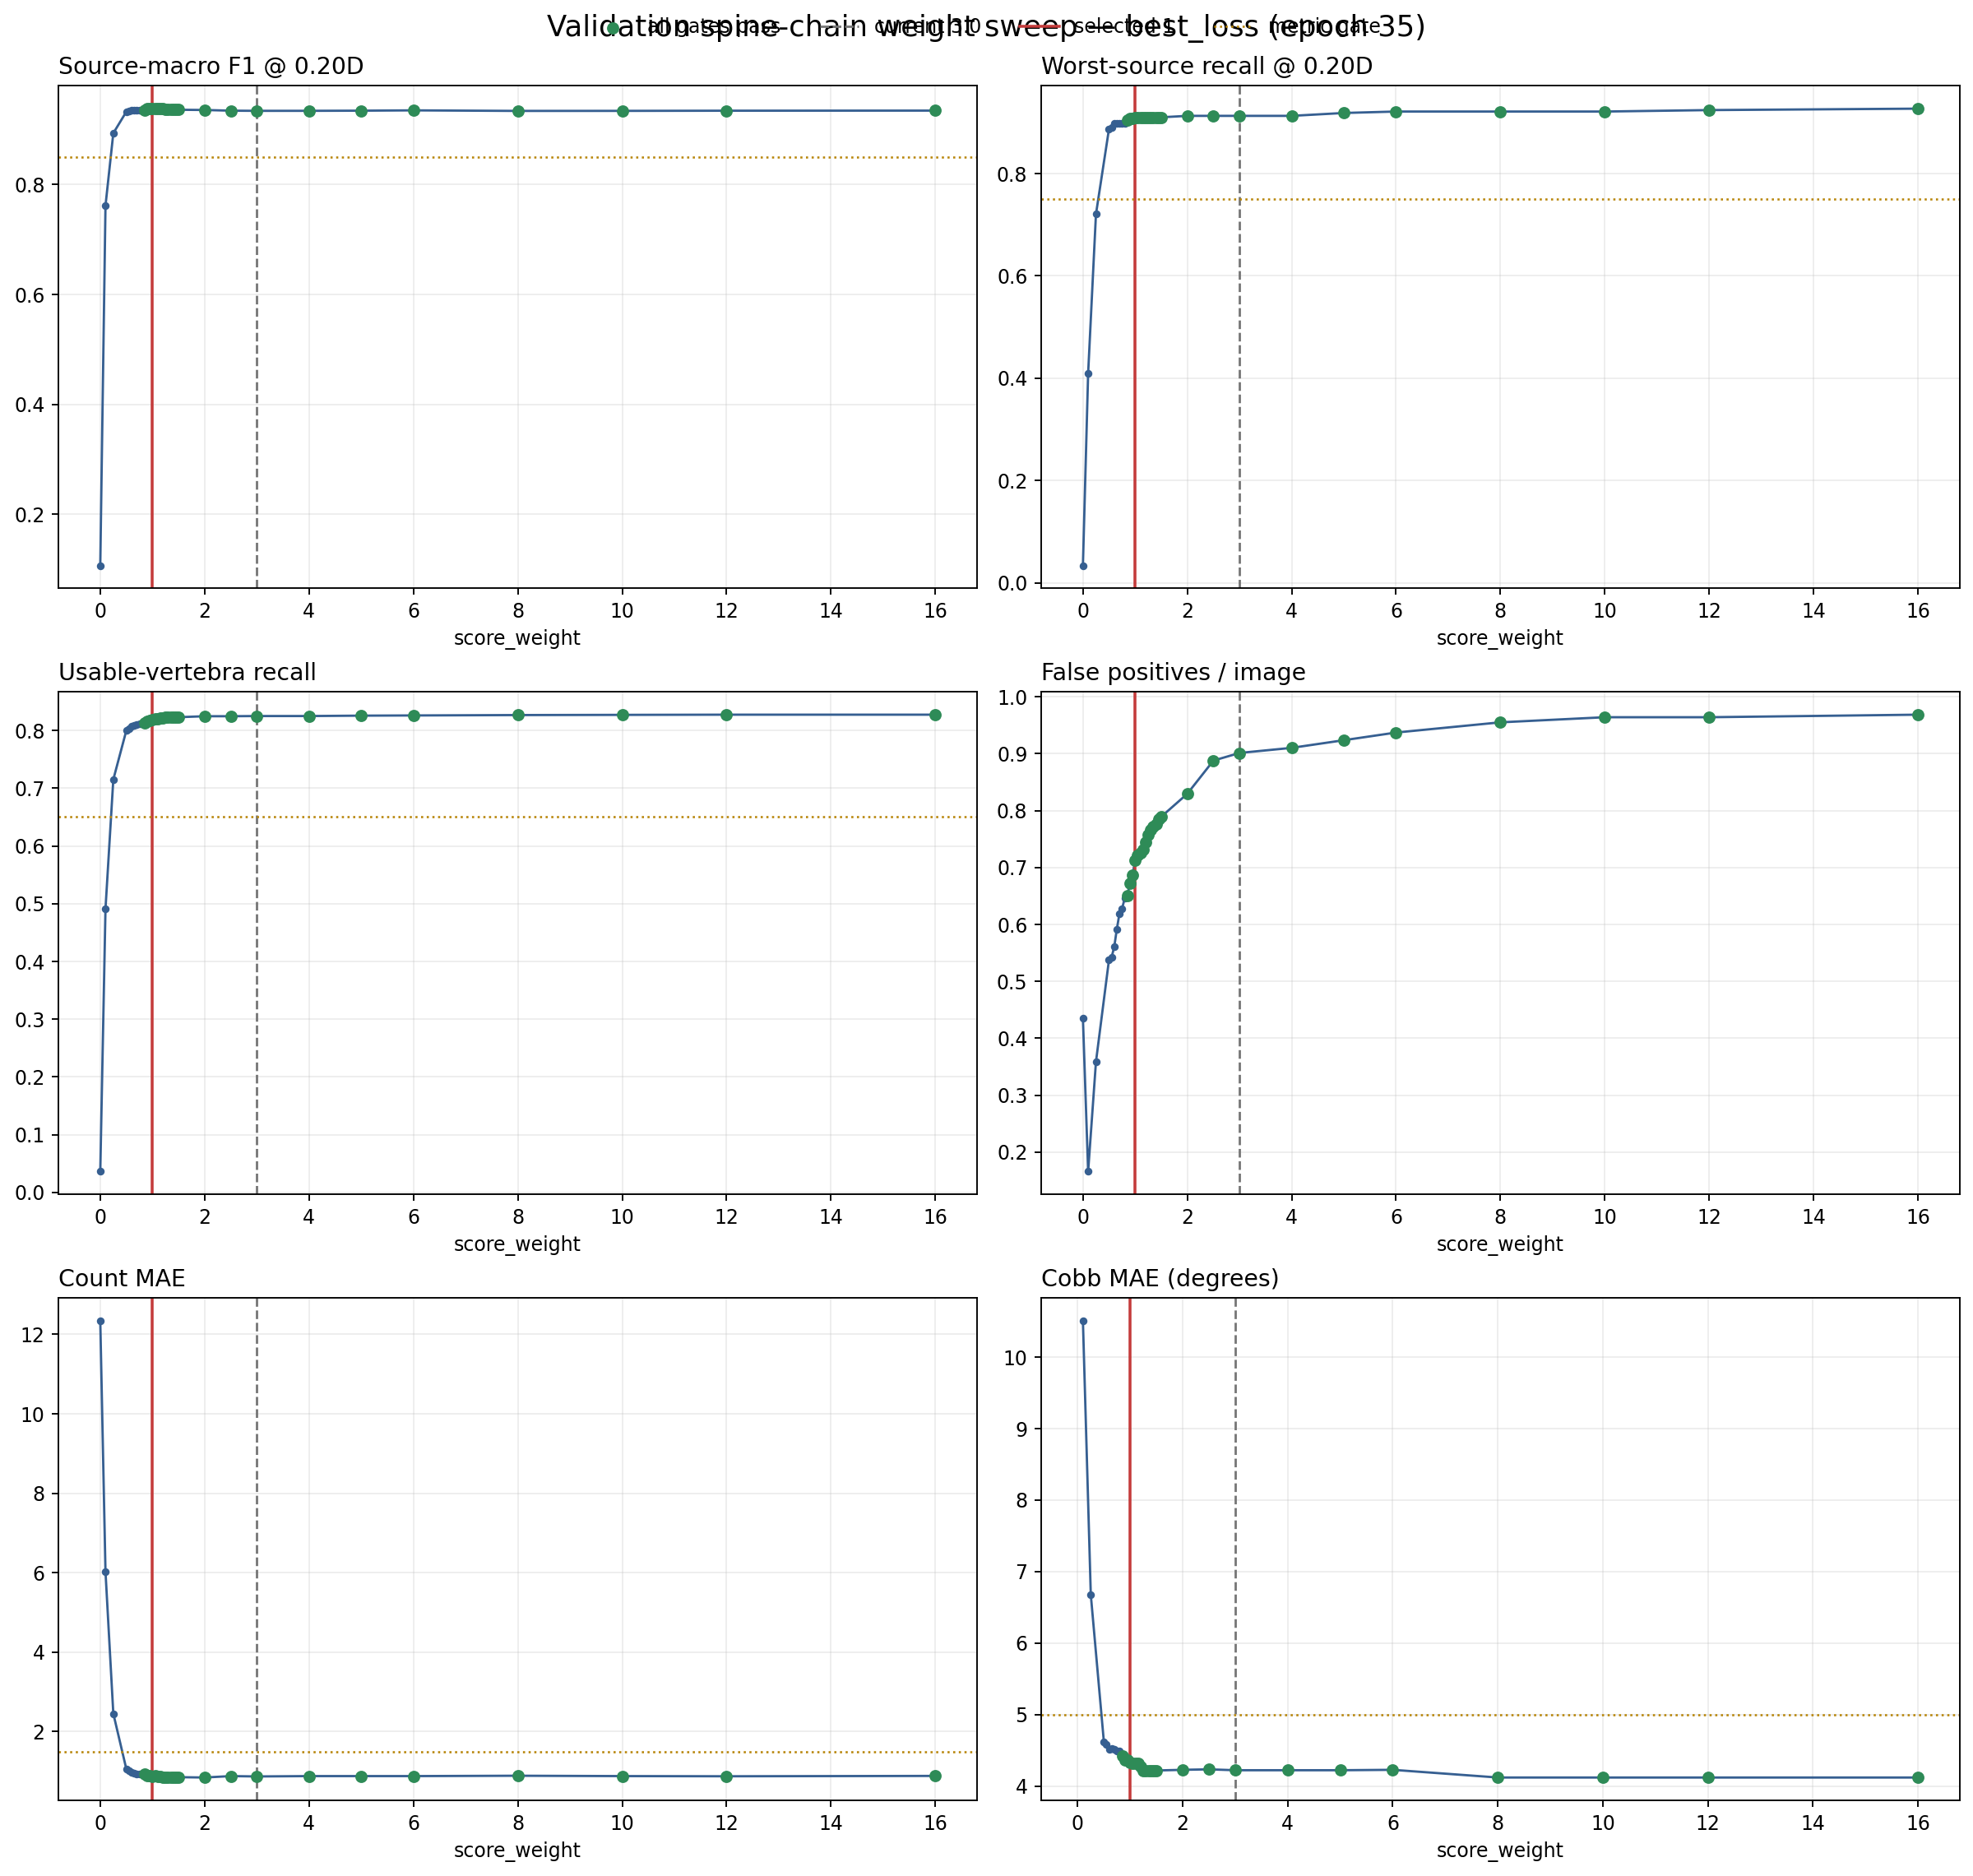

In [ ]:
lines = ["### Validation-selected recommendations", ""]
for item in frozen_from_disk["ranked_recommendations"]:
    metrics = item["selected_metrics"]
    qualification = "passed all gates" if item["qualified"] else "best observed but did not pass every gate"
    lines.append(
        f"- **#{item['validation_rank']} {item['model']} (epoch {item['epoch']}):** "
        f"`score_weight={item['selected_weight']:g}`; {qualification}. "
        f"Validation source-macro F1@0.20D={metrics['source_macro_center_f1_0.20d']:.4f}, "
        f"worst-source recall={metrics['worst_source_center_recall_0.20d']:.4f}, "
        f"usable recall={metrics['overall_usable_vertebra_recall']:.4f}, "
        f"FP/image={metrics['overall_false_positives_per_image']:.4f}, "
        f"count MAE={metrics['overall_count_mae']:.4f}."
    )

lines.extend(["", "### Frozen test confirmation", ""])
for _, row in test_winner_rows.sort_values("model").iterrows():
    lines.append(
        f"- **{row['model']}:** weight `{row['weight']:g}` produced test "
        f"source-macro F1@0.20D={row['source_macro_center_f1_0.20d']:.4f}, "
        f"worst-source recall={row['worst_source_center_recall_0.20d']:.4f}, "
        f"usable recall={row['overall_usable_vertebra_recall']:.4f}, "
        f"FP/image={row['overall_false_positives_per_image']:.4f}, "
        f"count MAE={row['overall_count_mae']:.4f}."
    )

lines.extend([
    "",
    "The overall recommendation remains the validation winner; the test split was not used for model or weight selection.",
    "",
    "These are technical screening-support measurements, not evidence that an image proves a spinal condition.",
])
display(Markdown("\n".join(lines)))

artifact_rows = []
for path in sorted(ARTIFACT_DIR.rglob("*")):
    if path.is_file():
        artifact_rows.append({
            "artifact": str(path.relative_to(EXPERIMENT_DIR)),
            "size_kb": round(path.stat().st_size / 1024, 1),
        })
display(pd.DataFrame(artifact_rows))

for run in validation_runs.values():
    display(DisplayImage(filename=str(run["figure_path"])))
